In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
data = pd.read_csv('PlayTennis.csv')

data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [3]:
data.shape

(14, 5)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Outlook      14 non-null     str  
 1   Temperature  14 non-null     str  
 2   Humidity     14 non-null     str  
 3   Wind         14 non-null     str  
 4   Play Tennis  14 non-null     str  
dtypes: str(5)
memory usage: 996.0 bytes


In [5]:
data.isnull().sum()

Outlook        0
Temperature    0
Humidity       0
Wind           0
Play Tennis    0
dtype: int64

In [6]:
data['Play Tennis'].value_counts()

Play Tennis
Yes    9
No     5
Name: count, dtype: int64

In [7]:
X = data.drop('Play Tennis', axis=1)
y = data['Play Tennis']

X.head()

,Outlook,Temperature,Humidity,Wind
0,Sunny,Hot,High,Weak
1,Sunny,Hot,High,Strong
2,Overcast,Hot,High,Weak
3,Rain,Mild,High,Weak
4,Rain,Cool,Normal,Weak


In [8]:
y.head()

0     No
1     No
2    Yes
3    Yes
4    Yes
Name: Play Tennis, dtype: str

In [9]:
encoders = {}

for column in X.columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    encoders[column] = le

X.head()

,Outlook,Temperature,Humidity,Wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1


In [10]:
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

y

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0])

In [11]:
X

,Outlook,Temperature,Humidity,Wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1
5,1,0,1,0
6,0,0,1,0
7,2,2,0,1
8,2,0,1,1
9,1,2,1,1


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (11, 4)
Testing data: (3, 4)


In [13]:
clf = CategoricalNB()

In [14]:
clf.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[0., 2...[3., 3., 1.]]), array([[1., 2...[2., 2., 3.]]), array([[3., 1... [2., 5.]]), array([[3., 1... [2., 5.]])]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[4.,7.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-1.01,-0.45]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-1.94...-1.60943791]]), array([[-1.25...-0.91629073]]), array([[-0.40...-0.40546511]]), array([[-0.40...-0.40546511]])]"


In [15]:
y_pred = clf.predict(X_test)

y_pred

array([1, 1, 1])

In [16]:
print("Actual values:")
print(y_test)

print("\nPredicted values:")
print(y_pred)

Actual values:
[0 1 1]

Predicted values:
[1 1 1]


In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6666666666666666


In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[0 1]
 [0 2]]


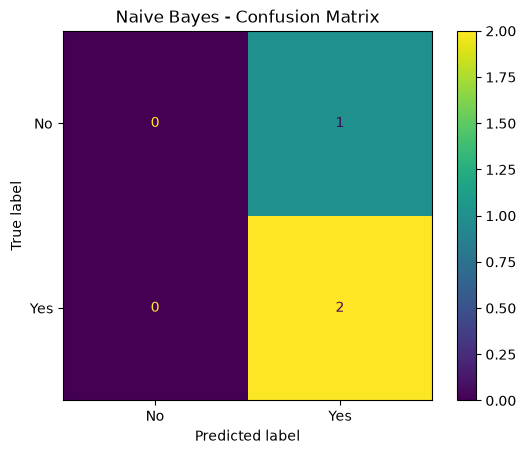

In [19]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot()

plt.title("Naive Bayes - Confusion Matrix")
plt.show()

In [20]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          No       0.00      0.00      0.00         1
         Yes       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



In [21]:
y_prob = clf.predict_proba(X_test)

y_prob

array([[0.46656299, 0.53343701],
       [0.36832413, 0.63167587],
       [0.22573363, 0.77426637]])

In [22]:
new_data = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
})

new_data

,Outlook,Temperature,Humidity,Wind
0,Sunny,Cool,High,Strong


In [23]:
for column in new_data.columns:
    new_data[column] = encoders[column].transform(new_data[column])

new_data

,Outlook,Temperature,Humidity,Wind
0,2,0,0,0


In [24]:
prediction = clf.predict(new_data)

prediction_label = target_encoder.inverse_transform(prediction)

print("Prediction:", prediction_label[0])

Prediction: No


In [25]:
probability = clf.predict_proba(new_data)

for class_name, prob in zip(
    target_encoder.classes_,
    probability[0]
):
    print(f"{class_name}: {prob:.4f}")

No: 0.8235
Yes: 0.1765


In [26]:
print("Naive Bayes Classifier")
print("----------------------")
print("Model:", clf)
print("Accuracy:", accuracy)
print("Prediction for new data:", prediction_label[0])

Naive Bayes Classifier
----------------------
Model: CategoricalNB()
Accuracy: 0.6666666666666666
Prediction for new data: No
